# Агентная SIR: миграция и население

Исследуем равные и разные размеры городов при общей численности 3000.

## Рабочее окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## По 18 прогонов на конфигурацию

In [2]:
rows = DataFrame[]
for (label, population) in
    (("equal", [1000, 1000, 1000]), ("unequal", [500, 1000, 1500]))
    result = migration_scan(
        "sir_migration_effect__param/$(label)";
        Ns = population,
    )
    result.grouped[!, :configuration] =
        fill(label, nrow(result.grouped))
    push!(rows, result.grouped)
end

## Время достижения пика

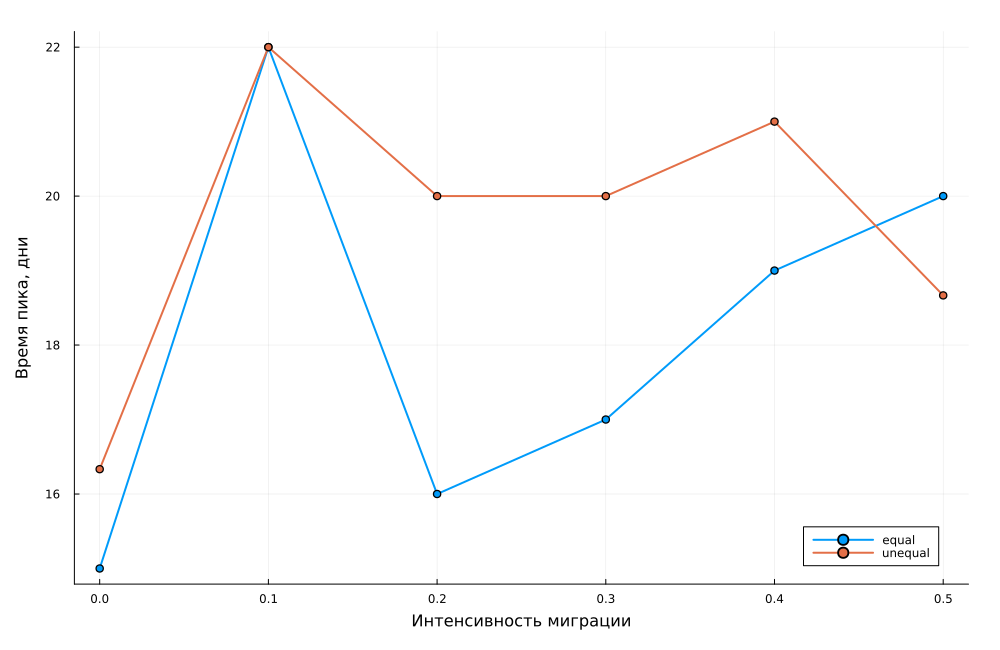

Row,intensity,peak_time,peak,configuration
,Float64,Float64,Float64,String
1,0.0,15.0,0.333259,equal
2,0.1,22.0,1.0,equal
3,0.2,16.0,1.0,equal
4,0.3,17.0,1.0,equal
5,0.4,19.0,1.0,equal
6,0.5,20.0,1.0,equal
7,0.0,16.3333,0.166667,unequal
8,0.1,22.0,1.0,unequal
9,0.2,20.0,1.0,unequal


In [3]:
summary = reduce(vcat, rows)
CSV.write(
    datafile("sir_migration_effect__param", "summary.csv"),
    summary,
)
figure = plot(;
    xlabel = "Интенсивность миграции",
    ylabel = "Время пика, дни",
)
for label in ("equal", "unequal")
    subset = summary[summary.configuration .== label, :]
    plot!(
        figure,
        subset.intensity,
        subset.peak_time;
        label,
        marker = :circle,
    )
end
savefig(figure, imagefile("08-plot.png"))
display(figure)
summary